# Step 3 - Baseline Reconstruction
This notebook reviews the great-circle baseline built from the cleaned Step 2 flights.
It shows the saved outputs, the error profile, and a few representative flights.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from aero_fusion.step3_baseline import Step3Config, run_step3_baseline

## Notebook Configuration
Set the review or build mode here.
The default path is safe and reads existing outputs without modifying the official artifacts.


In [2]:
RUN_STEP3_BUILD = False
BUILD_MODE = "full"   # options: "review", "preview", "full"
ALLOW_OVERWRITE_OUTPUT_ROOT = True

STEP2_ROOT = PROJECT_ROOT / "artifacts" / "step2_clean"
STEP3_FULL_ROOT = PROJECT_ROOT / "artifacts" / "step3_baseline"
STEP3_PREVIEW_ROOT = PROJECT_ROOT / "artifacts" / "step3_baseline_preview"

MAX_PREVIEW_FLIGHTS = 25
PROGRESS_EVERY = 25

In [3]:
if BUILD_MODE not in {"review", "preview", "full"}:
    raise ValueError("BUILD_MODE must be one of: review, preview, full")

if BUILD_MODE == "review":
    TARGET_STEP3_ROOT = STEP3_FULL_ROOT
elif BUILD_MODE == "preview":
    TARGET_STEP3_ROOT = STEP3_PREVIEW_ROOT
else:
    TARGET_STEP3_ROOT = STEP3_FULL_ROOT

config_view = pd.DataFrame(
    {
        "setting": [
            "run_step3_build",
            "build_mode",
            "allow_overwrite_output_root",
            "step2_root",
            "target_step3_root",
            "max_preview_flights",
            "progress_every",
        ],
        "value": [
            RUN_STEP3_BUILD,
            BUILD_MODE,
            ALLOW_OVERWRITE_OUTPUT_ROOT,
            str(STEP2_ROOT),
            str(TARGET_STEP3_ROOT),
            MAX_PREVIEW_FLIGHTS,
            PROGRESS_EVERY,
        ],
    }
)
config_view

,setting,value
0,run_step3_build,False
1,build_mode,full
2,allow_overwrite_output_root,True
3,step2_root,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
4,target_step3_root,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
5,max_preview_flights,25
6,progress_every,25


## Build Guard
`review` reads the saved results, `preview` writes to a sandbox path, and `full` rebuilds the official Step 3 artifacts.
The guard is there to keep accidental rebuilds away from the final dataset.


In [4]:
step2_catalog_path = STEP2_ROOT / "catalog" / "clean_flights_validated.parquet"
if not step2_catalog_path.exists():
    raise FileNotFoundError(f"Missing Step 2 validated catalog: {step2_catalog_path}")

step2_validated = pd.read_parquet(step2_catalog_path).copy()
print(f"Step 2 validated flights: {len(step2_validated)}")
step2_validated.head()

Step 2 validated flights: 1704


,segment_id,source_run,icao24,flight_callsign,segment_start_time,segment_end_time,flight_start_time,flight_end_time,gap_duration_minutes,adsc_point_count_step1,...,clean_flight_dir,clean_adsb_before_path,clean_adsc_path,clean_adsb_after_path,clean_stitched_path,standardized_stitched_path,cleaning_metadata_path,source_master_metadata_path,window_type,geo_ok
0,20230708_0101e0_115103_124631,step1_raw_20230707_20230731,0101e0,MSR987,2023-07-08 11:51:03,2023-07-08 12:46:31,2023-07-08 07:10:23,2023-07-08 17:09:55,55.466667,5,...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,day-window (old),True
1,20230708_040203_105633_115102,step1_raw_20230707_20230731,040203,ETH552,2023-07-08 10:56:33,2023-07-08 11:51:02,2023-07-08 09:53:08,2023-07-08 16:04:25,54.483333,5,...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,day-window (old),True
2,20230708_3965b0_114354_124236,step1_raw_20230707_20230731,3965b0,AFR022,2023-07-08 11:43:54,2023-07-08 12:42:36,2023-07-08 09:56:02,2023-07-08 16:50:27,58.700000,6,...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,day-window (old),True
3,20230708_4005bb_132246_150522,step1_raw_20230707_20230731,4005bb,BAW17R,2023-07-08 13:22:46,2023-07-08 15:05:22,2023-07-08 11:50:52,2023-07-08 18:20:55,102.600000,8,...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,day-window (old),True
4,20230708_4005be_135507_151954,step1_raw_20230707_20230731,4005be,BAW17A,2023-07-08 13:55:07,2023-07-08 15:19:54,2023-07-08 12:33:14,2023-07-08 19:06:34,84.783333,8,...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,day-window (old),True


## Optional Step 3 Build
Run this cell only when you want to regenerate baseline outputs.
For normal review, leave the build flag off and inspect the saved files below.


In [5]:
step3_summary = None

if RUN_STEP3_BUILD:
    if BUILD_MODE == "review":
        raise ValueError("RUN_STEP3_BUILD=True is not allowed with BUILD_MODE='review'. Use 'preview' or 'full'.")
    if not ALLOW_OVERWRITE_OUTPUT_ROOT:
        raise ValueError("Set ALLOW_OVERWRITE_OUTPUT_ROOT = True before rebuilding Step 3 outputs.")

    cfg = Step3Config(
        step2_root=STEP2_ROOT,
        output_root=TARGET_STEP3_ROOT,
        write_per_flight_outputs=True,
        max_flights_to_process=(MAX_PREVIEW_FLIGHTS if BUILD_MODE == "preview" else None),
        progress_every=PROGRESS_EVERY,
        clean_existing_output=True,
        verbose=True,
    )
    step3_summary = run_step3_baseline(cfg)
    step3_summary
else:
    print("RUN_STEP3_BUILD is False -> review mode only, no Step 3 rebuild performed.")

RUN_STEP3_BUILD is False -> review mode only, no Step 3 rebuild performed.


## Load Saved Step 3 Outputs
This section loads the catalog and metrics already produced by Step 3.
It is the standard entry point for review and presentation runs.


In [6]:
step3_metrics_path = TARGET_STEP3_ROOT / "catalog" / "baseline_metrics.parquet"
step3_issues_path = TARGET_STEP3_ROOT / "catalog" / "baseline_issues.parquet"
step3_summary_path = TARGET_STEP3_ROOT / "catalog" / "baseline_summary.json"

if not step3_metrics_path.exists():
    raise FileNotFoundError(
        f"Missing Step 3 metrics at {step3_metrics_path}. "
        "Build Step 3 first or point BUILD_MODE to an existing Step 3 output folder."
    )

baseline_metrics = pd.read_parquet(step3_metrics_path).copy()
baseline_issues = pd.read_parquet(step3_issues_path).copy() if step3_issues_path.exists() else pd.DataFrame()
baseline_summary = pd.read_json(step3_summary_path, typ="series") if step3_summary_path.exists() else pd.Series(dtype=object)

print(f"Baseline flights evaluated: {len(baseline_metrics)}")
print(f"Baseline issues rows      : {len(baseline_issues)}")
baseline_summary

Baseline flights evaluated: 1704
Baseline issues rows      : 0


flights_evaluated                                      1704
baseline_method                   great_circle_time_aligned
mean_of_mean_error_m                          132110.105965
median_of_mean_error_m                        114324.444878
mean_rmse_error_m                             140433.797172
median_rmse_error_m                           121909.069416
mean_max_error_m                              181152.639314
median_max_error_m                            157155.450148
mean_path_length_abs_error_m                   40904.890451
median_path_length_abs_error_m                 33220.157048
dtype: object

## Baseline Metrics Overview
These summaries show how the great-circle baseline performs across the test set.
They provide the reference line for every later method comparison.


In [7]:
baseline_metrics[[
    "segment_id",
    "flight_callsign",
    "adsc_point_count_step2",
    "mean_error_m",
    "median_error_m",
    "rmse_error_m",
    "max_error_m",
    "path_length_abs_error_m",
]].head(10)

,segment_id,flight_callsign,adsc_point_count_step2,mean_error_m,median_error_m,rmse_error_m,max_error_m,path_length_abs_error_m
0,20230708_0101e0_115103_124631,MSR987,5,85350.899376,98329.206029,89076.125222,107866.632338,48308.094128
1,20230708_040203_105633_115102,ETH552,5,67841.846156,71356.073635,68434.586463,74220.029007,29381.221048
2,20230708_3965b0_114354_124236,AFR022,6,67671.692598,73716.726794,68991.006102,78538.919041,4994.312097
3,20230708_4005bb_132246_150522,BAW17R,8,38601.253988,37315.631967,38851.598797,44800.412503,2386.967573
4,20230708_4005be_135507_151954,BAW17A,8,96548.920300,98970.185012,97734.837123,112771.466881,54073.543116
5,20230708_4006c2_143857_154752,BAW43C,10,49938.409260,44170.532484,54291.482442,76666.757511,46646.249890
6,20230708_400772_152055_161044,BAW22G,6,94625.713362,107896.482504,98567.005573,111098.783701,7898.489487
7,20230708_4b1885_133319_150945,SWR6A,6,65912.087916,71332.865256,67126.771581,77398.203802,62068.918472
8,20230708_4bb18f_125053_134938,THY69W,6,174195.573794,199039.106673,179573.384867,207912.200266,65365.745722
9,20230708_70209e_134512_145123,BBC305,6,71094.917593,72882.860936,77793.631662,108088.478843,85633.947652


In [8]:
overview = baseline_metrics[[
    "mean_error_m",
    "median_error_m",
    "rmse_error_m",
    "max_error_m",
    "path_length_abs_error_m",
    "anchor_gap_m",
    "true_path_length_m",
    "pred_path_length_m",
]].describe(percentiles=[0.5, 0.9, 0.95]).T
overview

,count,mean,std,min,50%,90%,95%,max
mean_error_m,1704.0,1.321101e+05,83381.329296,5517.844201,1.143244e+05,2.352576e+05,2.817400e+05,6.073041e+05
median_error_m,1704.0,1.393697e+05,91397.469145,5517.844201,1.189787e+05,2.538599e+05,3.099919e+05,6.555036e+05
rmse_error_m,1704.0,1.404338e+05,86201.047843,6459.110324,1.219091e+05,2.488511e+05,3.008461e+05,6.124763e+05
max_error_m,1704.0,1.811526e+05,108562.644511,8203.828113,1.571555e+05,3.207537e+05,3.946792e+05,7.785018e+05
path_length_abs_error_m,1704.0,4.090489e+04,33078.018386,11.236456,3.322016e+04,8.482738e+04,1.032099e+05,2.311808e+05
anchor_gap_m,1704.0,3.666510e+06,596622.551638,465931.692667,3.448792e+06,4.405356e+06,4.743589e+06,6.353693e+06
true_path_length_m,1704.0,1.251659e+06,436497.610529,8892.402319,1.157625e+06,1.824481e+06,2.052168e+06,4.003727e+06
pred_path_length_m,1704.0,1.262092e+06,429792.400939,9478.075667,1.180835e+06,1.821716e+06,2.042580e+06,3.868646e+06


## Error Distributions
These plots show the spread of baseline reconstruction error, not just the average.
Use them to separate typical behavior from the long-error tail.


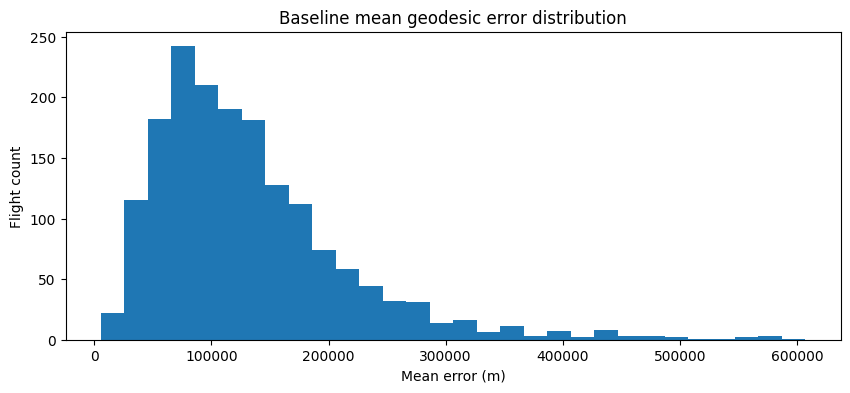

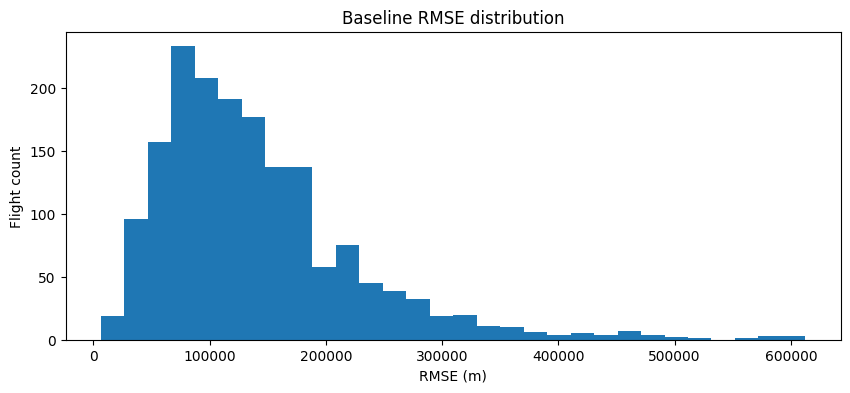

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
baseline_metrics["mean_error_m"].plot(kind="hist", bins=30, ax=ax)
ax.set_title("Baseline mean geodesic error distribution")
ax.set_xlabel("Mean error (m)")
ax.set_ylabel("Flight count")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
baseline_metrics["rmse_error_m"].plot(kind="hist", bins=30, ax=ax)
ax.set_title("Baseline RMSE distribution")
ax.set_xlabel("RMSE (m)")
ax.set_ylabel("Flight count")
plt.show()

## Relationship Between Truth Complexity and Baseline Error
This section checks whether harder trajectories systematically break the baseline.
It helps explain where a learned model should gain the most.


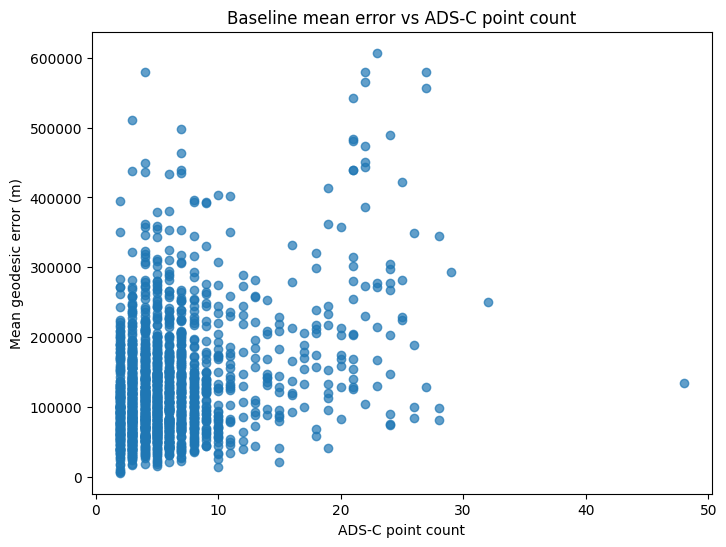

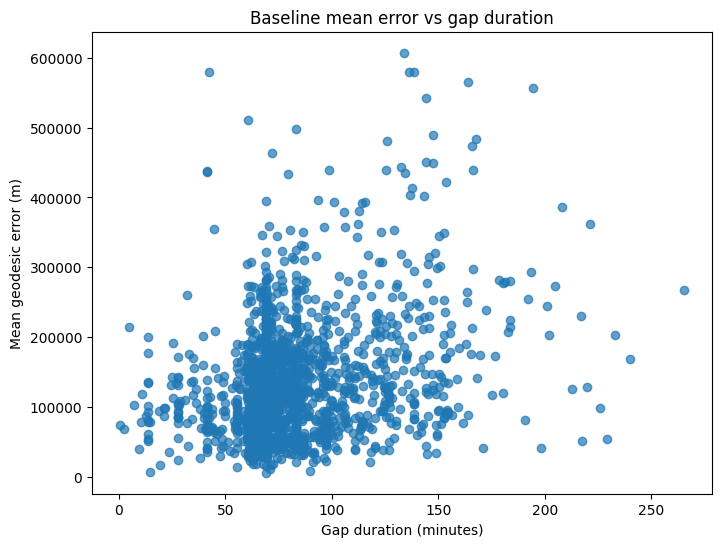

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    baseline_metrics["adsc_point_count_step2"],
    baseline_metrics["mean_error_m"],
    alpha=0.7,
)
ax.set_title("Baseline mean error vs ADS-C point count")
ax.set_xlabel("ADS-C point count")
ax.set_ylabel("Mean geodesic error (m)")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    baseline_metrics["gap_duration_minutes"],
    baseline_metrics["mean_error_m"],
    alpha=0.7,
)
ax.set_title("Baseline mean error vs gap duration")
ax.set_xlabel("Gap duration (minutes)")
ax.set_ylabel("Mean geodesic error (m)")
plt.show()

## Worst and Best Flights
These examples show the edges of baseline performance.
They are useful for explaining both the method ceiling and its failure cases.


In [11]:
best_flights = baseline_metrics.sort_values("mean_error_m").head(10)
worst_flights = baseline_metrics.sort_values("mean_error_m", ascending=False).head(10)

print("Best flights:")
display(best_flights[["segment_id", "flight_callsign", "mean_error_m", "rmse_error_m", "max_error_m"]])

print("Worst flights:")
display(worst_flights[["segment_id", "flight_callsign", "mean_error_m", "rmse_error_m", "max_error_m"]])

Best flights:


,segment_id,flight_callsign,mean_error_m,rmse_error_m,max_error_m
1015,20240901_a8cecd_051452_062412,LXJ667,5517.844201,6459.110324,8875.447744
53,20230711_06a03d_134427_135922,QTR1379,6708.193207,6872.901853,8203.828113
968,20240822_4851ae_062450_075438,KLM618,8662.005643,9278.503770,11987.707141
1128,20241009_a2b6fd_011930_023017,N274SW,10703.677723,12612.018338,17374.081741
61,20230713_407cd1_120515_130044,BAW72A,13217.115221,15115.995709,22816.401642
357,20231109_48436a_030021_040924,KLM662,14948.354379,16548.272369,24963.210501
69,20230715_040187_101955_103909,ETH574,16140.633379,16511.995720,19622.867830
921,20240816_4bb0ea_054436_065552,THY9LC,16656.230267,24964.570727,42797.980154
651,20240507_3c4a8c_120635_131404,DLH400,17775.404217,23064.123802,32471.962034
110,20230814_a05669_100858_112119,UAL90,17939.432104,18716.197178,23949.016536


Worst flights:


,segment_id,flight_callsign,mean_error_m,rmse_error_m,max_error_m
1701,20250801_400684_195403_220753,BAW37J,607304.084428,612476.321890,675521.734959
1463,20250215_34659a_200802_205020,IBE0337,579815.911578,584132.291387,650472.069042
1679,20250703_4005c0_202353_224235,BAW183,579481.313488,592457.913069,697415.343199
1678,20250703_4005bc_175820_201434,BAW189,579334.422086,594287.089043,726042.151583
1677,20250703_3c4591_203217_231609,BOX450,566020.199151,572186.314497,651833.513909
1702,20250801_400774_203353_234805,BAW183,556857.050044,590708.712098,778501.763973
1596,20250327_4b1882_170613_193029,SWR72,541854.183790,553356.241643,631247.423715
687,20240524_aa6ccb_105816_115901,AAL95,510918.283613,522147.427429,600194.582710
1262,20241205_4005c0_220823_233136,BAW37J,498163.101317,501125.412300,557944.290385
1700,20250801_4005bb_105232_131959,BAW7NY,488945.823984,505319.199704,626910.925178


## Example Flight Inspection
This detailed example overlays the saved baseline against the reference trajectory.
Use it to verify geometry and anchor behavior on a real segment.


In [12]:
example_segment_id = str(baseline_metrics.sort_values("mean_error_m").iloc[0]["segment_id"])
example_segment_id

'20240901_a8cecd_051452_062412'

In [13]:
example_pred_path = TARGET_STEP3_ROOT / "flights" / example_segment_id / "baseline_prediction.parquet"
if not example_pred_path.exists():
    raise FileNotFoundError(
        f"Missing per-flight baseline prediction at {example_pred_path}. "
        "Run Step 3 with write_per_flight_outputs=True."
    )

example_prediction = pd.read_parquet(example_pred_path).copy()
example_prediction.head()

,segment_id,timestamp,fraction_of_gap,pred_latitude,pred_longitude,true_latitude,true_longitude,anchor_start_time,anchor_end_time,anchor_start_latitude,...,true_altitude_m,pred_geoaltitude_m,true_geoaltitude_m,pred_baroaltitude_m,true_baroaltitude_m,pred_velocity_mps,true_velocity_mps,pred_heading_deg,true_heading_deg,point_error_m
0,20240901_a8cecd_051452_062412,2024-09-01 05:14:52,0.633745,49.09047,-29.191422,49.035244,-29.103470,2024-09-01 02:57:20,2024-09-01 06:34:21,45.607452,...,NaN,NaN,NaN,13497.560390,NaN,NaN,NaN,NaN,NaN,8875.447744
1,20240901_a8cecd_051452_062412,2024-09-01 06:24:12,0.953229,47.89635,-14.082772,47.877045,-14.086018,2024-09-01 02:57:20,2024-09-01 06:34:21,45.607452,...,NaN,NaN,NaN,13694.752249,NaN,NaN,NaN,NaN,NaN,2160.240657


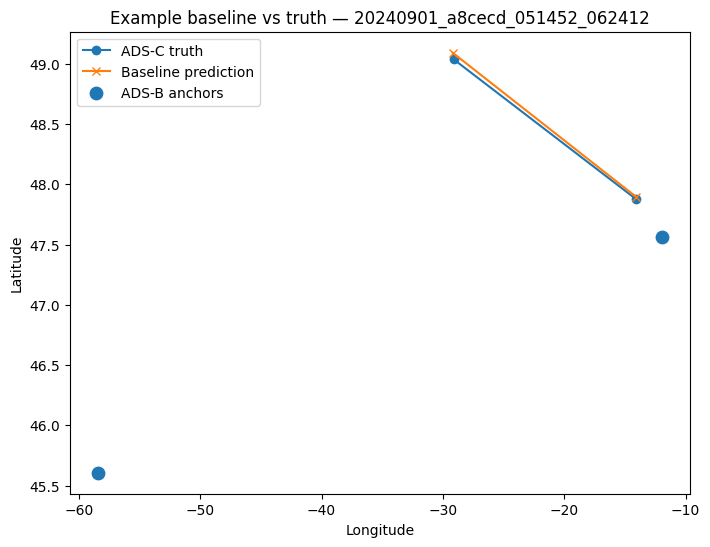

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(
    example_prediction["true_longitude"],
    example_prediction["true_latitude"],
    marker="o",
    label="ADS-C truth",
)
ax.plot(
    example_prediction["pred_longitude"],
    example_prediction["pred_latitude"],
    marker="x",
    label="Baseline prediction",
)
ax.scatter(
    [example_prediction["anchor_start_longitude"].iloc[0], example_prediction["anchor_end_longitude"].iloc[0]],
    [example_prediction["anchor_start_latitude"].iloc[0], example_prediction["anchor_end_latitude"].iloc[0]],
    s=80,
    label="ADS-B anchors",
)
ax.set_title(f"Example baseline vs truth — {example_segment_id}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.show()

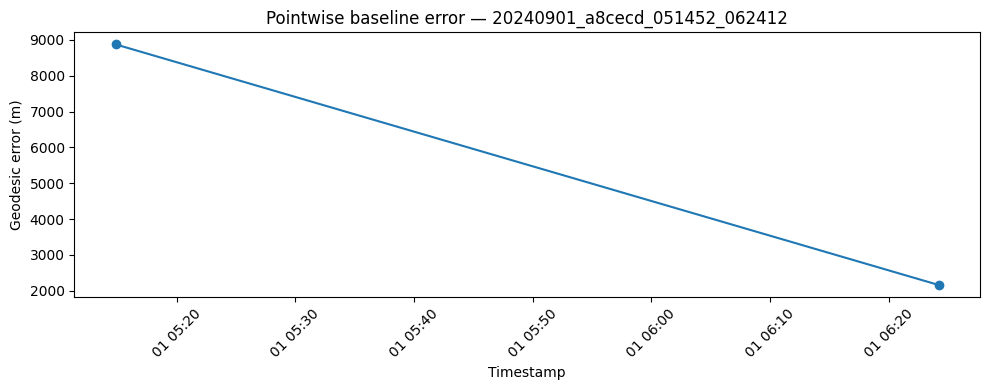

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(example_prediction["timestamp"], example_prediction["point_error_m"], marker="o")
ax.set_title(f"Pointwise baseline error — {example_segment_id}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Geodesic error (m)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Final Notes
The saved Step 3 outputs are the baseline reference for Kalman and GRU evaluation.
Keep them stable unless you are intentionally rebuilding the cleaned dataset chain.


### Normal Usage
Run the notebook in review mode to inspect the official Step 3 artifacts.
Use preview or full rebuilds only when you need to refresh outputs on purpose.
